
# <center>**ClarIA: Claim Assistance Resolution**</center>

---

**Técnicas de Inteligencia Artificial - Deep Learning**

**Martina Ibarra | Elena Salomon | Florencia Nebot**

---


# Introducción y motivación

Las empresas reciben miles de quejas de consumidores diariamente
pero carecen de herramientas para identificar automáticamente los problemas. Actualmente, las quejas se analizan
manualmente o se clasifican sólo superficialmente por producto/categoría, sin
detectar las causas raíz que podrían prevenir futuras quejas si se corrigen. Esto genera desperdicio de recursos reaccionando a síntomas individuales en lugar de resolver problemas estructurales.

En este proyecto proponemos el desarrollo de un agente inteligente basado en Deep Learning que, mediante técnicas de Retrieval-Augmented Generation (RAG) y Ollama, permite consultar el dataset de quejas financieras en lenguaje natural. El sistema no solo recupera registros relevantes, sino que genera respuestas analíticas que ayudan a identificar:

1. Principales problemas por producto financiero

2. Tendencias emergentes

3. Áreas críticas que requieren atención estratégica

Este enfoque permite transformar un conjunto masivo de comentarios no estructurados en insights accionables para la toma de decisiones.


**Dataset**

https://www.kaggle.com/datasets/selener/consumer-complaint-database

**Metadata**

* **"Date received"**: La fecha en que la CFPB recibió la queja.
* **"Product"**: El tipo de producto que el consumidor identificó en la queja.
* **"Sub-product"**: El tipo de subproducto que el consumidor identificó en la queja.
* **"Issue"**: El problema que el consumidor identificó en la queja.
* **"Sub-issue"**: El subproblema que el consumidor identificó en la queja.
* **"Consumer complaint narrative"**: Descripción del consumidor sobre "lo que sucedió" en la queja.
* **"Company public response"**: La respuesta opcional y pública de la empresa a la queja del consumidor.
* **"Company"**: La empresa sobre la que trata la queja.
* **"State"**: El estado de la dirección de correo proporcionada por el consumidor.
* **"ZIP code"**: El código postal de envío proporcionado por el consumidor.
* **"Tags"**: Datos que facilitan la búsqueda y clasificación de las quejas.
* **"Consumer consent provided?"**: Identifica si el consumidor optó por publicar el relato de su queja.
* **"Submitted via"**: Cómo se envió la queja a la CFPB.
* **"Date sent to company"**: La fecha en que la CFPB envió la queja a la empresa.
* **"Company response to consumer"**: Cómo respondió la empresa.
* **"Timely response?"**: Si la empresa dio una respuesta a tiempo.
* **"Consumer disputed?"**: Si el consumidor disputed la respuesta de la empresa.
* **"Complaint ID"**: El número de identificación único para una queja.

https://cfpb.github.io/api/ccdb/fields.html

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn datasets transformers torch sentence-transformers umap-learn hdbscan faiss-cpu langchain langchain-community langchain-experimental ollama

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 115.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [2]:
# Importamos librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
import hdbscan
import umap
import time
import faiss
import subprocess
import spacy

from tqdm.auto import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding, DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

from langchain_community.llms import Ollama
from langchain_experimental.agents import create_pandas_dataframe_agent
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import create_sql_agent
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
# Instalamos mas librerias.
#!pip install pandas matplotlib seaborn langchain langchain-text-splitters

In [ ]:
# Quitar el límite del ancho de las columnas para leer comentarios
pd.set_option('display.max_colwidth', None)


In [3]:
# Nos conectamos a nuestra cuenta de Google Drive para acceder a los datos.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path = '/content/drive/MyDrive/Colab Notebooks/MIT/ClarIA/rows.csv'
#path = '/content/drive/MyDrive/Diploma UTEC/Deep Learning/ClarIA/rows.csv'
df = pd.read_csv(path)

/tmp/ipython-input-469/1219101543.py:3: DtypeWarning: Columns (4,5,6,11,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


# Tratamiento de datos y análisis exploratorio

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 18 columns):
 #   Column                        Non-Null Count    Dtype 
---  ------                        --------------    ----- 
 0   Date received                 1282355 non-null  object
 1   Product                       1282355 non-null  object
 2   Sub-product                   1047189 non-null  object
 3   Issue                         1282355 non-null  object
 4   Sub-issue                     751169 non-null   object
 5   Consumer complaint narrative  383564 non-null   object
 6   Company public response       449082 non-null   object
 7   Company                       1282355 non-null  object
 8   State                         1262955 non-null  object
 9   ZIP code                      1167057 non-null  object
 10  Tags                          175643 non-null   object
 11  Consumer consent provided?    690654 non-null   object
 12  Submitted via                 1282355 non-

In [7]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,Checking account,Managing an account,Banking errors,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460


In [8]:
#Eliminamos columnas que no son relevantes para nuestro proyecto
df = df.drop(columns=['State', 'ZIP code', 'Tags', 'Consumer consent provided?','Company public response'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 13 columns):
 #   Column                        Non-Null Count    Dtype 
---  ------                        --------------    ----- 
 0   Date received                 1282355 non-null  object
 1   Product                       1282355 non-null  object
 2   Sub-product                   1047189 non-null  object
 3   Issue                         1282355 non-null  object
 4   Sub-issue                     751169 non-null   object
 5   Consumer complaint narrative  383564 non-null   object
 6   Company                       1282355 non-null  object
 7   Submitted via                 1282355 non-null  object
 8   Date sent to company          1282355 non-null  object
 9   Company response to consumer  1282348 non-null  object
 10  Timely response?              1282355 non-null  object
 11  Consumer disputed?            768501 non-null   object
 12  Complaint ID                  1282355 non-

**Observaciones**

Este dataset de quejas de la CFPB cuenta con 1.282.355 registros, donde campos clave como Product, Issue y Company están totalmente completos. Sin embargo, dado que el objetivo es desarrollar un sistema de resolucion de quejas, la columna crítica es Consumer complaint narrative, ya que contiene el texto semántico que el modelo de lenguaje necesita para "leer" y responder consultas. Como solo el 30% de las quejas (383.564 registros) incluyen este relato, limpiaremos el dataset para quedarnos únicamente con las filas donde esta columna está completa, asegurando que nuestro buscador de FAISS e inteligencia artificial trabaje solo con datos que aporten contexto real y no con entradas vacías.

## Nulos y Duplicados

In [10]:
# 1. Definir la columna clave
col_comentarios = 'Consumer complaint narrative'

# 2. Contar nulos
nulos = df[col_comentarios].isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

# 3. Contar duplicados (solo en la columna de texto, ignorando nulos)
# Filtramos los nulos primero para que no cuenten como duplicados entre sí
comentarios_validos = df[df[col_comentarios].notnull()][col_comentarios]
duplicados = comentarios_validos.duplicated().sum()
porcentaje_duplicados = (duplicados / len(comentarios_validos)) * 100

# 4. Mostrar resultados formateados
print("=== Auditoría del Dataset ===")
print(f"Total de registros: {len(df):,}")
print(f"Comentarios Nulos:  {nulos:,} ({porcentaje_nulos:.2f}%)")
print(f"Comentarios Duplicados: {duplicados:,} ({porcentaje_duplicados:.2f}%)")

# 5. Visualizar un par de ejemplos duplicados (para entender por qué se repiten)
if duplicados > 0:
    print("\n--- Ejemplo de comentarios que se repiten ---")
    print(comentarios_validos[comentarios_validos.duplicated()].head(2).values)

=== Auditoría del Dataset ===
Total de registros: 1,282,355
Comentarios Nulos:  898,791 (70.09%)
Comentarios Duplicados: 16,619 (4.33%)

--- Ejemplo de comentarios que se repiten ---
['There are many mistakes appear in my report without my understanding.'
 'There are many mistakes appear in my report without my understanding.']


**Observaciones**
Se encontraron nulos y duplicados, procederemos a eliminar estos comentarios para no perder capacidad RAM procesando información repetida, ni tampoco generar errores de ejecución por datos vacíos.



In [11]:
#Nos quedamos unicamente con las filas que tienen el claim escrito y eliminamos
df_filtered = df[df['Consumer complaint narrative'].notna()]
df_clean = df_filtered.drop_duplicates(subset=['Consumer complaint narrative'])

## Selección de datos

Revisamos las empresas de las cuales tenemos reclamos.

Como tenemos diversidad de tipos de empresas, le pasamos el listado a Gemini para que nos ayude a clasificar las empresas según su tipo. De esta forma podremos quedarnos unicamente con los bancos.

Consideramos que la naturaleza de los reclamos y la normativa aplicable difieren significativamente según el tipo de institución financiera (ej. Bancos vs. Bureau de crédito). Al centrarnos solo en bancos, garantizamos que el análisis de los reclamos sea consistente y comparable.

In [12]:
def clasificar_entidad(nombre):
    nombre = str(nombre).upper()

    # 1. OTROS (Filtramos primero lo que NO es servicio directo o es B2B)
    otros_keywords = [
        'LLP', 'LLC', 'PC', 'PLLC', 'ATTORNEY', 'LAW', 'LEGAL', 'RECOVERY',
        'COLLECTION', 'ADJUSTMENT', 'ARBITRATION', 'BUREAU', 'EQUIFAX',
        'EXPERIAN', 'TRANSUNION', 'ACRANET', 'SERVICES', 'MANAGEMENT'
    ]
    if any(k in nombre for k in otros_keywords):
        return "Otros"

    # 2. FINTECH & E-BANKING (Marcas digitales específicas)
    fintech_ebanking = {
        'COINBASE': 'Fintech', 'PAYPAL': 'Fintech', 'XOOM': 'Fintech',
        'BITCOIN': 'Fintech', 'XAPO': 'Fintech', 'WINKLEVOSS': 'Fintech',
        'ALLY': 'e-banking', 'SCHWAB': 'e-banking', 'CHASE': 'Banco', # Chase es tradicional
        'NETSPEND': 'Fintech', 'SQUARE': 'Fintech', 'VENMO': 'Fintech'
    }
    for key, val in fintech_ebanking.items():
        if key in nombre:
            return val

    # 3. BANCOS (Palabras clave de banca tradicional)
    banco_keywords = ['BANK', 'BANCORP', 'BANCORPORATION', 'NATIONAL ASSOCIATION', 'N.A.', 'TRUST']
    if any(k in nombre for k in banco_keywords):
        return "Banco"

    # 4. PRESTADORAS DE CRÉDITO (Consumo, Hipotecas y Autos)
    prestadora_keywords = [
        'MORTGAGE', 'LENDING', 'LOAN', 'FINANCE', 'FINANCIAL', 'CREDIT',
        'ACCEPTANCE', 'FUNDING', 'CASH', 'MONEY', 'HONDA', 'FORD', 'NISSAN',
        'BMW', 'TOYOTA', 'HYUNDAI', 'CHRYSLER'
    ]
    if any(k in nombre for k in prestadora_keywords):
        return "Prestadora de crédito"

    # 5. DEFAULT (Si no entra en ninguna, lo mandamos a otros para revisión)
    return "Otros"

# --- EJECUCIÓN ---

df_clean['Categoria_Negocio'] = df_clean['Company'].apply(clasificar_entidad)

print("Distribución de la clasificación:")
print(df_clean['Categoria_Negocio'].value_counts())

# Ver una muestra de la clasificación
display(df_clean[['Company', 'Categoria_Negocio']].drop_duplicates().head(20))

Distribución de la clasificación:
Categoria_Negocio
Otros                    248272
Banco                     59343
Prestadora de crédito     52381
Fintech                    5033
e-banking                  1916
Name: count, dtype: int64


/tmp/ipython-input-469/3264552494.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Categoria_Negocio'] = df_clean['Company'].apply(clasificar_entidad)


,Company,Categoria_Negocio
29904,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Otros
34111,Experian Information Solutions Inc.,Otros
34357,First Federal Credit Control,Prestadora de crédito
35071,"Patriot Finance, LLC",Otros
35079,"Ability Recovery Services, LLC",Otros
35163,"McCarthy, Burgess & Wolff, Inc.",Otros
35265,"SELECT PORTFOLIO SERVICING, INC.",Otros
35319,"NRA Group, LLC",Otros
35946,RUSHMORE LOAN MANAGEMENT SERVICES LLC,Otros
36271,"VANDERBILT MORTGAGE & FINANCE, INC",Prestadora de crédito


In [13]:
# Agrupamos por la categoría asignada y verificamos algunas compañias por tipo de empresa
ejemplos_por_tipo = df_clean.groupby('Categoria_Negocio')['Company'].unique().apply(lambda x: x[:10])

for categoria, empresas in ejemplos_por_tipo.items():
    print(f"=== TIPO DE NEGOCIO: {categoria} ===")
    for i, nombre in enumerate(empresas, 1):
        print(f"  {i}. {nombre}")
    print("-" * 30)

=== TIPO DE NEGOCIO: Banco ===
  1. CITIBANK, N.A.
  2. JPMORGAN CHASE & CO.
  3. M&T BANK CORPORATION
  4. DISCOVER BANK
  5. COMMERCE BANK
  6. FLAGSTAR BANK, FSB
  7. U.S. BANCORP
  8. SUNTRUST BANKS, INC.
  9. VALLEY NATIONAL BANCORP
  10. BANK OF AMERICA, NATIONAL ASSOCIATION
------------------------------
=== TIPO DE NEGOCIO: Fintech ===
  1. XOOM CORPORATION
  2. NETSPEND CORPORATION
  3. PAYPAL HOLDINGS INC.
  4. Coinbase, Inc.
  5. SQUARETWO FINANCIAL CORPORATION
  6. Xapo, Inc.
------------------------------
=== TIPO DE NEGOCIO: Otros ===
  1. TRANSUNION INTERMEDIATE HOLDINGS, INC.
  2. Experian Information Solutions Inc.
  3. Patriot Finance, LLC
  4. Ability Recovery Services, LLC
  5. McCarthy, Burgess & Wolff, Inc.
  6. SELECT PORTFOLIO SERVICING, INC.
  7. NRA Group, LLC
  8. RUSHMORE LOAN MANAGEMENT SERVICES LLC
  9. TekCollect Inc.
  10. Upstart Holdings, Inc.
------------------------------
=== TIPO DE NEGOCIO: Prestadora de crédito ===
  1. First Federal Credit Contro

In [14]:
df_clean = df_clean[df_clean['Categoria_Negocio'] == 'Banco'].copy()

/tmp/ipython-input-469/2661603538.py:36: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_time = df_clean.set_index('Date received').resample('M').size()


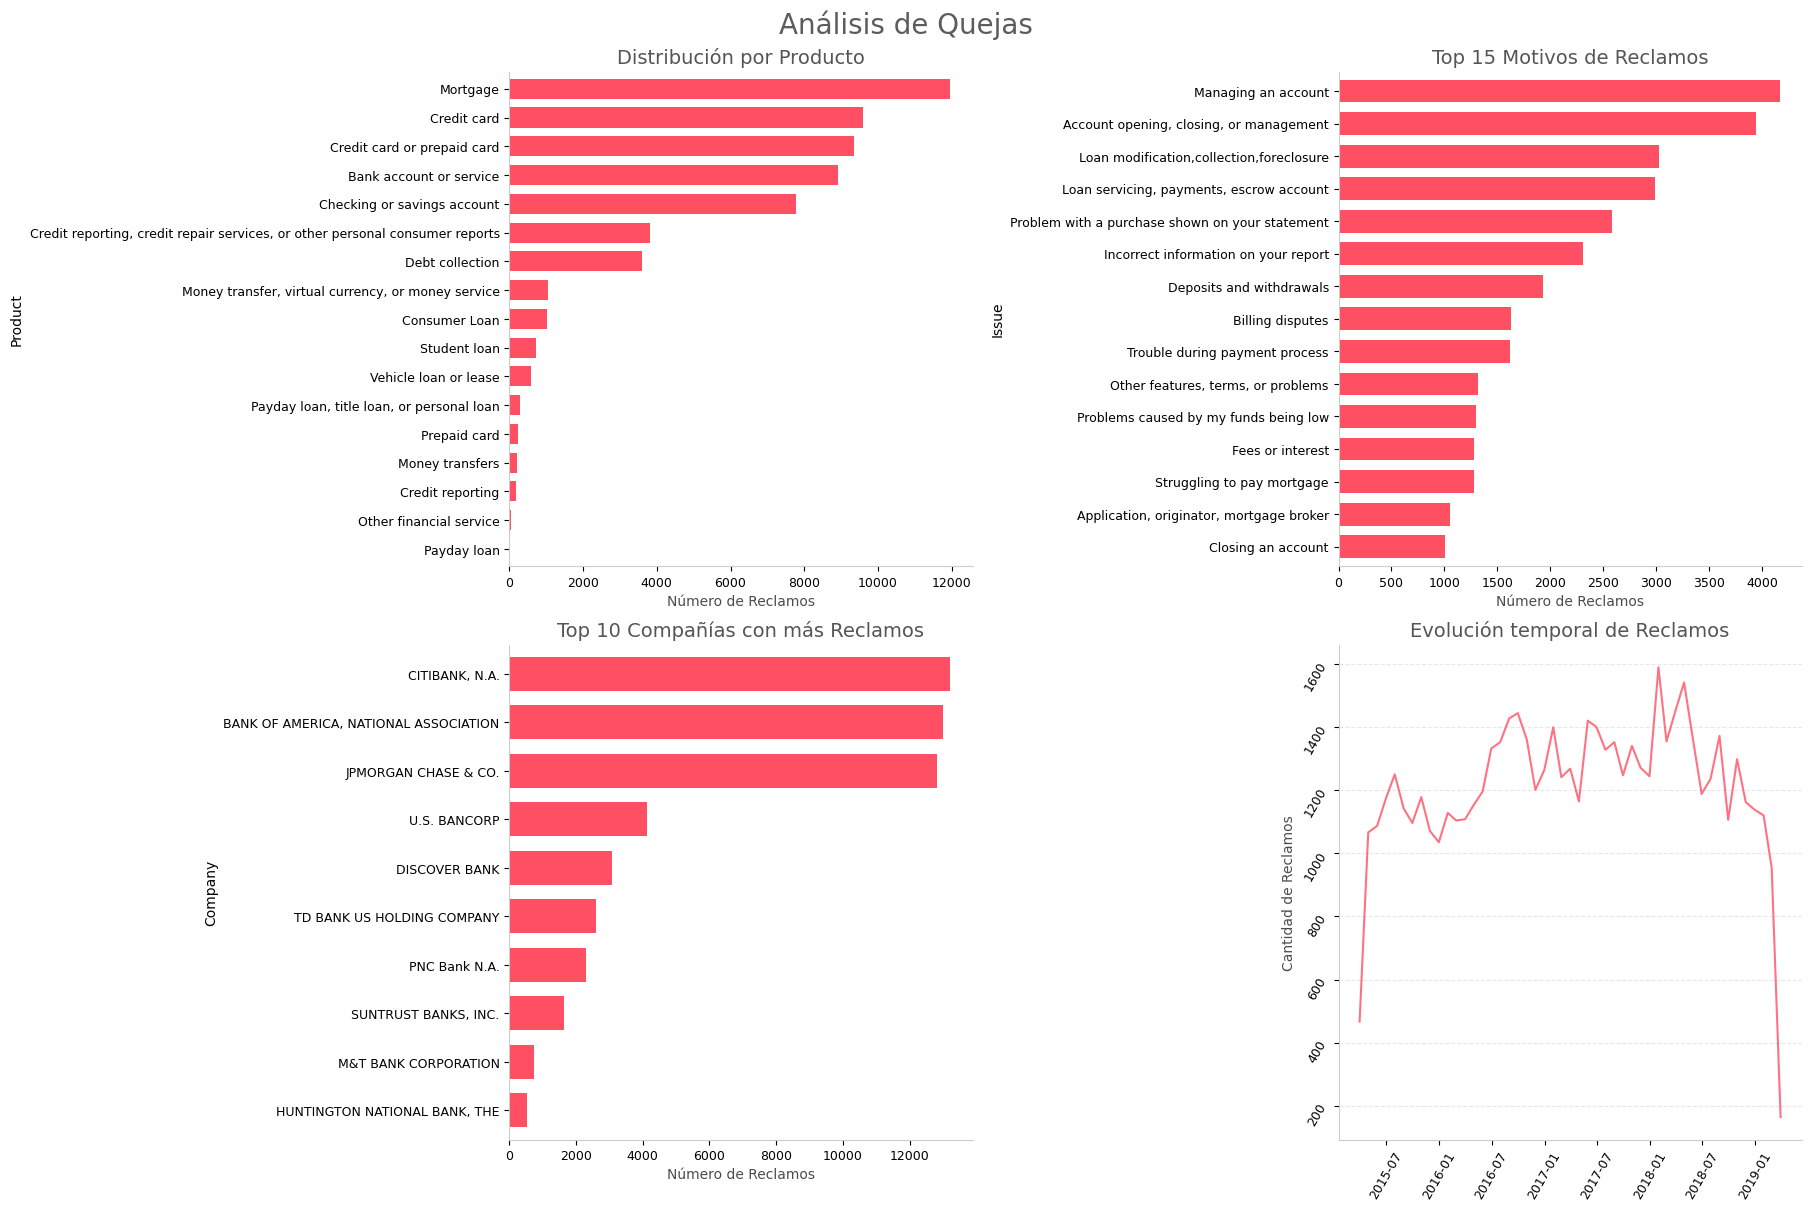

In [15]:
# Configuración de paleta de colores
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] # Una fuente limpia y legible
color_claria = '#ff4f63'

# 1. Preparación de la figura
# Usamos constrained_layout=True para que los tamaños sean idénticos y proporcionales
fig, axs = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
fig.suptitle('Análisis de Quejas',
             fontsize=20, color='#333333', alpha=0.8)

# --- Subplot 1: Distribución por Producto ---
data_prod = df_clean['Product'].value_counts().sort_values(ascending=True)
data_prod.plot(kind='barh', ax=axs[0, 0], color=color_claria, width=0.7)
axs[0, 0].set_title('Distribución por Producto', fontsize=14, color='#555555')
axs[0, 0].set_xlabel('Número de Reclamos', fontsize=10, alpha=0.7)
axs[0, 0].tick_params(labelsize=9)

# --- Subplot 2: Top 15 Motivos (Issue) ---
data_issue = df_clean['Issue'].value_counts().head(15).sort_values(ascending=True)
data_issue.plot(kind='barh', ax=axs[0, 1], color=color_claria, width=0.7)
axs[0, 1].set_title('Top 15 Motivos de Reclamos', fontsize=14, color='#555555')
axs[0, 1].set_xlabel('Número de Reclamos', fontsize=10, alpha=0.7)
axs[0, 1].tick_params(labelsize=9)

# --- Subplot 3: Top 10 Compañías ---
data_comp = df_clean['Company'].value_counts().head(10).sort_values(ascending=True)
data_comp.plot(kind='barh', ax=axs[1, 0], color=color_claria, width=0.7)
axs[1, 0].set_title('Top 10 Compañías con más Reclamos', fontsize=14, color='#555555')
axs[1, 0].set_xlabel('Número de Reclamos', fontsize=10, alpha=0.7)
axs[1, 0].tick_params(labelsize=9)

# --- Subplot 4: Tendencia Temporal ---
# Resampleamos por mes para la línea de tendencia
df_clean['Date received'] = pd.to_datetime(df_clean['Date received'])
data_time = df_clean.set_index('Date received').resample('M').size()
axs[1, 1].plot(data_time.index, data_time.values, color=color_claria, linewidth=1.5, alpha=0.8)
axs[1, 1].set_title('Evolución temporal de Reclamos', fontsize=14, color='#555555')
axs[1, 1].set_ylabel('Cantidad de Reclamos', fontsize=10, alpha=0.7)
axs[1, 1].grid(axis='y', linestyle='--', alpha=0.3)
axs[1, 1].tick_params(labelsize=9, rotation=60)

# Eliminamos bordes innecesarios (spines) para un look más moderno
for ax in axs.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

plt.show()

**Observaciones**

Para este análisis, aplicaremos un filtro de segmentación para enfocarnos exclusivamente en la banca tradicional, conservando solo los registros clasificados como "Banco" y eliminando el resto de las categorías (Fintech, Prestadoras de crédito, etc.). El objetivo de esta depuración es eliminar el "ruido" que generan otros sectores financieros con modelos de negocio distintos.

Del análisis descriptivo de los datos de los registros de bancos podemos ver:
1. Una alta concentración de demanda en productos de Mortgage (Hipotecas) y Credit Cards (tarjetas de crédito), estos representan el mayor volumen de reclamos.

2. Los motivos principales ("Managing an account" y "Account opening") indican que las causas raíz no son solo fallas financieras, sino problemas en la experiencia de usuario y trámites burocráticos.

3. El volumen está fuertemente inclinado hacia tres entidades principales (Citibank, BoA, JPMorgan). Para el agente, esto implica que debe ser capaz de distinguir entre quejas generales del sistema y problemas específicos de la operativa de cada banco.

4. Inestabilidad Temporal: La tendencia muestra picos de actividad (especialmente hacia 2018) que sugieren eventos sistémicos. El agente automático permitiría detectar estos "picos" en tiempo real, pasando de una reacción tardía a una solución proactiva de problemas estructurales.

### **Tratamiento de datos**

Al trabajar con comentarios, sabemos que el lenguaje humano es ruidoso por defecto, para que nuestro modelo no aprenda sobre ese ruido, eliminaremos elementos que no aportan valor semántico pero que sí generan confusión en los modelos de inteligencia artificial.
1. Eliminar outliers
2. Estandarizar a minúsculas
3. Remover el ruido de la anonimización (las secuencias de "X", por datos confidenciales)
4. Limpiar caracteres especiales


In [16]:
# 1. Calculamos la longitud de las narrativas en el dataset muestreado
df_clean['longitud'] = df_clean['Consumer complaint narrative'].str.len()

# 2. Calculamos los estadísticos principales (Cuartiles)
estadisticos = df_clean['longitud'].describe(percentiles=[.25, .50, .75, .90, .95])

# 3. Definimos outliers usando el método de Rango Intercuartílico (IQR)
Q1 = estadisticos['25%']
Q3 = estadisticos['75%']
IQR = Q3 - Q1
limite_superior_iqr = Q3 + 1.5 * IQR
limite_inferior_iqr = Q1 - 1.5 * IQR

# 4. Conteo de outliers
outliers_superiores = df_clean[df_clean['longitud'] > limite_superior_iqr]
outliers_inferiores = df_clean[df_clean['longitud'] < limite_inferior_iqr] # Basado en nuestro criterio de calidad

print("--- ANÁLISIS DE LONGITUD DE CARACTERES ---")
print(estadisticos)
print("\n--- DETECCIÓN DE OUTLIERS ---")
print(f"Límite superior estadístico (IQR): {int(limite_superior_iqr)} caracteres")
print(f"Cantidad de quejas 'eterno-largas' (> IQR): {len(outliers_superiores)}")
print(f"Cantidad de quejas 'muy cortas' (< IQR): {len(outliers_inferiores)}")

--- ANÁLISIS DE LONGITUD DE CARACTERES ---
count    59343.000000
mean      1344.829382
std       1324.902219
min         13.000000
25%        539.000000
50%        986.000000
75%       1724.000000
90%       2871.000000
95%       3735.000000
max      31385.000000
Name: longitud, dtype: float64

--- DETECCIÓN DE OUTLIERS ---
Límite superior estadístico (IQR): 3501 caracteres
Cantidad de quejas 'eterno-largas' (> IQR): 3701
Cantidad de quejas 'muy cortas' (< IQR): 0


In [17]:
# Filtramos un pequeño subconjunto que esté cerca de los 150 caracteres
ejemplos_frontera = df_clean[df_clean['Consumer complaint narrative'].str.len().between(140, 160)]

print(f"Se encontraron {len(ejemplos_frontera)} quejas en el rango de 140-160 caracteres.\n")

# Mostramos las primeras 3 para analizar su "riqueza" de información
for i, texto in enumerate(ejemplos_frontera['Consumer complaint narrative'].head(3), 1):
    print(f"Ejemplo {i} ({len(texto)} caracteres):")
    print(f"'{texto}'")
    print("-" * 50)

Se encontraron 460 quejas en el rango de 140-160 caracteres.

Ejemplo 1 (156 caracteres):
'5 year + old charge off account. 
Discover bank keep going up on total amount. I was told the account will be XXXX soon. 

Balance should be $ 800-1000 max.'
--------------------------------------------------
Ejemplo 2 (152 caracteres):
'Deposited into my account a check on XX/XX/19. Bank has placed a hold on funds without providing sufficient reason and one not covered by Regulation CC.'
--------------------------------------------------
Ejemplo 3 (145 caracteres):
'Best Buy visa credit card raised the interest rate without notifying me of the rate and did not have my signature agreeing to that interest rate.'
--------------------------------------------------


In [18]:
MIN_CHARS = 100
MAX_CHARS = 1500

df_filtered = df_clean[
    (df_clean['Consumer complaint narrative'].str.len() >= MIN_CHARS) &
    (df_clean['Consumer complaint narrative'].str.len() <= MAX_CHARS)
].copy()

eliminados_cortos = len(df_clean[df_clean['Consumer complaint narrative'].str.len() < MIN_CHARS])
eliminados_largos = len(df_clean[df_clean['Consumer complaint narrative'].str.len() > MAX_CHARS])

print(f"--- REPORTE DE RECORTE ---")
print(f"✅ Quejas que pasaron el filtro: {len(df_filtered)}")
print(f"❌ Eliminadas por ser muy cortas (<{MIN_CHARS}): {eliminados_cortos}")
print(f"❌ Eliminadas por ser muy largas (>{MAX_CHARS}): {eliminados_largos}")

LIMITE_CASOS = 250

df_clean_dos = df_filtered.groupby('Product', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), LIMITE_CASOS), random_state=42)
)

--- REPORTE DE RECORTE ---
✅ Quejas que pasaron el filtro: 40293
❌ Eliminadas por ser muy cortas (<100): 897
❌ Eliminadas por ser muy largas (>1500): 18153


/tmp/ipython-input-469/299199199.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean_dos = df_filtered.groupby('Product', group_keys=False).apply(


In [19]:
def clean_complaints(text):
    if not isinstance(text, str): return ""
    # 1. Minúsculas
    text = text.lower()
    # 2. Borrar secuencias de X (xxxx, xx/xx/xxxx, etc.)
    text = re.sub(r'[x]{2,}', '', text)
    # 3. Borrar caracteres especiales y números (opcional pero recomendado)
    text = re.sub(r'[^a-z\s]', '', text)
    # 4. Limpiar espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Creamos la columna limpia
df_clean_dos['clean_narrative'] = df_clean_dos['Consumer complaint narrative'].apply(clean_complaints)

In [ ]:
# Configuramos pandas para que no corte el texto en la visualización
pd.set_option('display.max_colwidth', None)

# Creamos una vista estética con estilo CSS
df_clean_dos[['Consumer complaint narrative', 'clean_narrative']].head(1).style.set_properties(**{
    'text-align': 'left',
    'white-space': 'normal',
    'border': '1px solid #ccc'
}).set_table_styles([
    dict(selector='th', props=[('background-color', '#ff4f63'), ('color', 'white'), ('font-weight', 'bold')])
])

,Consumer complaint narrative,clean_narrative
645795,I have been banking with TD Bank for approximately two years. I knew from the beginning that they were nothing but a bunch of crooks. They expect their customers to keep a specific balance in their checking account. I talked with the manager at the TD bank in XXXX about the {$15.00} service charge based on the balance. He agreed that it was not appropriate and refunded my money. It is my money and not this bunch of crooks. They took {$15.00} out about two months ago and I complained. They refunded the money. Now they have done it again and overdrew my account. CROOKS. I will change banks just as soon as my SS check is deposited. I hate the legal crooks that banks are. They provide no services.,i have been banking with td bank for approximately two years i knew from the beginning that they were nothing but a bunch of crooks they expect their customers to keep a specific balance in their checking account i talked with the manager at the td bank in about the service charge based on the balance he agreed that it was not appropriate and refunded my money it is my money and not this bunch of crooks they took out about two months ago and i complained they refunded the money now they have done it again and overdrew my account crooks i will change banks just as soon as my ss check is deposited i hate the legal crooks that banks are they provide no services


###**Submuestreo controlado**
Como vimos en las salidas anteriores, tenemos disparidad en cantidad de quejas entre productos, para que el modelo no quede sesgado hacia esos productos realizaremos una recategorización de productos y un submuestreo controlado, limitaremos cada categoría de producto a un máximo de 250 casos



In [20]:
# 1. Definimos un diccionario de productos para disminuir categorías de los mismos
mapa_categorias = {
    'Credit reporting, credit repair services, or other personal consumer reports': 'Credit Reporting',
    'Credit reporting': 'Credit Reporting',
    'Credit card or prepaid card': 'Cards',
    'Credit card': 'Cards',
    'Prepaid card': 'Cards',
    'Mortgage': 'Mortgages',
    'Checking or savings account': 'Banking Services',
    'Bank account or service': 'Banking Services',
    'Money transfer, virtual currency, or money service': 'Money Transfers',
    'Debt collection': 'Debt Collection',
    'Vehicle loan or lease': 'Loans',
    'Consumer Loan': 'Loans',
    'Student loan': 'Loans',
    'Payday loan, title loan, or personal loan': 'Loans'
}

df_clean_dos['Product_Consolidated'] = df_clean_dos['Product'].map(mapa_categorias).fillna('Other')


# 2. Aplicamos el Undersampling
LIMITE_CASOS = 250

df_sample = df_clean_dos.groupby('Product_Consolidated', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), LIMITE_CASOS), random_state=42)
)

df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribución consolidada y balanceada:")
print(df_sample['Product_Consolidated'].value_counts())

Distribución consolidada y balanceada:
Product_Consolidated
Mortgages           250
Banking Services    250
Debt Collection     250
Loans               250
Credit Reporting    250
Money Transfers     250
Cards               250
Other               191
Name: count, dtype: int64


/tmp/ipython-input-469/3460807980.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df_clean_dos.groupby('Product_Consolidated', group_keys=False).apply(


In [21]:
df_sample['Product_Consolidated'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1941 entries, 0 to 1940
Series name: Product_Consolidated
Non-Null Count  Dtype 
--------------  ----- 
1941 non-null   object
dtypes: object(1)
memory usage: 15.3+ KB


**Observaciones**

Al usar lacategorización, groupby y sample, garantizas que los productos con miles de quejas no eclipsen a los más pequeños, creando un subconjunto equitativo que acelera el procesamiento sin perder la diversidad de temas.

De un dataset que contenía casi 1.3M de filas, logramos uno de 1941 filas sin nulos, sin duplicados y más balanceado.

# Validación de queja

Implementamos un pipeline de Preprocesamiento Basado en Agentes que actúa como un evaluador de calidad. Este componente analiza la estructura lógica de la queja y determina su utilidad para el sistema RAG. Al identificar y etiquetar el 'Ruido' (comentarios sin sustancia o incoherentes) antes de la indexación vectorial, garantizamos que la base de conocimientos de ClarIA mantenga una alta densidad de información relevante, minimizando así las alucinaciones del modelo en la etapa de respuesta.

In [30]:
!pip install ollama

In [31]:
# 1. Instalamos la dependencia zstd
!sudo apt-get install -y zstd

# 2. Instalamos Ollama
!curl -fsSL https://ollama.com/install.sh | sh

# 3. Iniciamos el servidor en segundo plano
subprocess.Popen(['ollama', 'serve'])
time.sleep(15)

# 4. Descargamos el modelo para la clasificación
!ollama pull llama3.2

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.



In [32]:
# Verificamos si el archivo existe antes de lanzarlo´
import os
if os.path.exists('/usr/local/bin/ollama'):
    print("✅ Binario de Ollama encontrado.")
    # Lanzamos el servidor usando la ruta completa
    subprocess.Popen(['/usr/local/bin/ollama', 'serve'])
    print("⏳ Esperando 15 segundos a que el servidor inicie...")
    time.sleep(15)
else:
    print("❌ El binario no se encontró. Reintenta ejecutar la celda de instalación (paso 1).")

✅ Binario de Ollama encontrado.
⏳ Esperando 15 segundos a que el servidor inicie...


In [33]:
import subprocess
import time
import ollama

def iniciar_ollama():
    try:
        # Intentamos una comunicación rápida para ver si ya está prendido
        ollama.list()
        print("✅ Ollama ya está ejecutándose.")
    except Exception:
        print("⚠️ Ollama no responde. Intentando encenderlo...")
        # Ejecuta 'ollama serve' en segundo plano
        # shell=True es necesario en Windows; en Mac/Linux podrías no necesitarlo
        subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

        # Le damos unos segundos para que cargue antes de seguir
        time.sleep(5)
        print("🚀 Servidor Ollama iniciado.")

# Llamamos a la función
iniciar_ollama()

✅ Ollama ya está ejecutándose.


In [34]:
from tqdm.auto import tqdm

# Activamos la barra de progreso para Pandas
tqdm.pandas()

print(f"Iniciando el procesamiento de {len(df_sample)} quejas.")

Iniciando el procesamiento de 1941 quejas.


In [35]:
import json
import re

def filtro_completo_ollama(texto):
    try:
        prompt = f"""
        Classify if the following financial complaint is ACTIONABLE or NOISE.
        ACTIONABLE: Specific issue to fix (errors, fraud, disputes).
        NOISE: General venting, insults, or incoherent text.

        Text: "{str(texto)[:500]}"

        Response format: JSON with keys 'classification' and 'reason'

        """

        response = ollama.generate(model='llama3.2', prompt=prompt)
        res_text = response['response'].strip()

        # 1. Intentar extraer el JSON usando Regex (por si el modelo añade texto antes o después)
        match = re.search(r'\{.*\}', res_text, re.DOTALL)
        if match:
            res_text = match.group(0)

        # 2. Limpiar posibles caracteres extraños
        res_text = res_text.replace('\n', ' ').strip()

        res_json = json.loads(res_text)
        return res_json.get('classification', 'ACTIONABLE'), res_json.get('reason', 'Validated')

    except Exception as e:
        # Si el JSON viene mal formado, lo marcamos para revisarlo luego
        return "ACTIONABLE", f"Error de formato: {str(e)}"

In [37]:
import json

df_sample[['Filtro', 'Motivo_Filtro']] = df_sample['clean_narrative'].progress_apply(
    lambda x: pd.Series(filtro_completo_ollama(x))
)

# GUARDAMOS RESULTADOS
df_sample.to_csv('dataset_claria_clasificado.csv', index=False)

print("\n✅ ¡Procesamiento completado con éxito!")
print(f"Total de quejas procesadas: {len(df_sample)}")
print(f"Quejas descartadas como RUIDO: {len(df_sample[df_sample['Filtro'] == 'NOISE'])}")

  0%|          | 0/1941 [00:00<?, ?it/s]


✅ ¡Procesamiento completado con éxito!
Total de quejas procesadas: 1941
Quejas descartadas como RUIDO: 48


### **Observaciones**

El análisis de sentimiento con Ollama 3.2 reveló que solo un 2.47% de los comentarios (48 de 1941) carecían de valor o presentaban contenido incoherente. Estas entradas fueron excluidas de la base de datos. Esto nos mejora que el agente a definir recupere únicamente contextos con alta densidad informativa, incrementando la confiabilidad de las respuestas generadas y optimizando el uso de recursos computacionales

In [38]:
df_claria = df_sample[df_sample['Filtro'] == 'ACTIONABLE'].copy()

In [39]:
df_claria.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1893 entries, 0 to 1940
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date received                 1893 non-null   datetime64[ns]
 1   Product                       1893 non-null   object        
 2   Sub-product                   1678 non-null   object        
 3   Issue                         1893 non-null   object        
 4   Sub-issue                     812 non-null    object        
 5   Consumer complaint narrative  1893 non-null   object        
 6   Company                       1893 non-null   object        
 7   Submitted via                 1893 non-null   object        
 8   Date sent to company          1893 non-null   object        
 9   Company response to consumer  1893 non-null   object        
 10  Timely response?              1893 non-null   object        
 11  Consumer disputed?            936 n

# Agente - RAG

### **Optimizaciones previas al modelo**

In [40]:
def evaluate_chunking_configs(texts, configs):
    results = []
    examples = {}

    for config in configs:
        size = config['chunk_size']
        overlap = config['overlap']

        splitter = RecursiveCharacterTextSplitter(
            chunk_size=size,
            chunk_overlap=overlap,
            length_function=len
        )

        start_time = time.time()
        all_chunks = []
        for text in texts:
            all_chunks.extend(splitter.split_text(text))
        end_time = time.time()

        # Guardamos métricas
        avg_len = sum(len(c) for c in all_chunks) / len(all_chunks) if all_chunks else 0
        results.append({
            'chunk_size': size,
            'overlap': overlap,
            'total_chunks': len(all_chunks),
            'avg_chunk_length': avg_len,
            'time_sec': end_time - start_time
        })

        # Guardamos un ejemplo para ver cómo quedó
        examples[f"{size}_{overlap}"] = all_chunks[:3]

    return pd.DataFrame(results), examples

# Ahora puedes correr tu main sin importar nada externo
def main(df_input):
    texts = df_input['clean_narrative'].tolist()
    print(f"🚀 Procesando {len(texts)} quejas...")

    chunk_configs = [
        {"chunk_size": 200, "overlap": 20},
        {"chunk_size": 300, "overlap": 20},
        {"chunk_size": 400, "overlap": 20}
    ]

    results_df, examples = evaluate_chunking_configs(texts, chunk_configs)

    print("\n--- Resultados del Experimento ---")
    print(results_df)

    return results_df, examples

# Ejecutar
if 'df_sample' in globals():
    res, ex = main(df_claria)

🚀 Procesando 1893 quejas...

--- Resultados del Experimento ---
   chunk_size  overlap  total_chunks  avg_chunk_length  time_sec
0         200       20          7643        175.402591  0.753732
1         300       20          5263        247.472354  0.415983
2         400       20          4122        311.373605  0.323472


**Observaciones**

Realizamos un experimento de optimización de segmentación (chunking) para determinar la mejor manera de fragmentar tus textos antes de enviarlos al modelo. Utilizando el RecursiveCharacterTextSplitter, el script prueba tres configuraciones diferentes de tamaño de bloque (200, 300 y 400 caracteres) manteniendo un solapamiento (overlap) de 20 caracteres para asegurar que no se pierda el contexto entre fragmentos. El objetivo principal es medir cuántos bloques se generan, cuánto tiempo tarda el proceso y cuál es la longitud promedio de cada trozo, permitiéndote elegir el equilibrio perfecto entre detalle (bloques pequeños) y contexto completo (bloques grandes) para que tu futuro buscador sea lo más preciso posible.

La configuración de 300 caracteres es la más adecuada porque logra el equilibrio óptimo entre eficiencia computacional y riqueza contextual. Genera solo 5.263 fragmentos (un poco más de la opción de 400), reduce drásticamente la carga de procesamiento y los costos operativos del agente de IA, manteniendo al mismo tiempo bloques de texto lo suficientemente extensos para capturar la narrativa completa del problema sin segmentar ideas críticas.


Procederemos a realizar una Indexación Semántica, que es el motor que permite al agente "entender" y buscar quejas por su significado profundo en lugar de simples palabras clave.
1. Fragmentaremos quejas con la configuración previa.
2. Transformaremos esas quejas, mediante el modelo all-MiniLM-L6-v2, en embeddings. Representaciones numéricas del concepto de cada reclamo.
3. Organización de los vectores en un índice FAISS, una base de datos vectorial de alta velocidad que permite al sistema identificar instantáneamente patrones comunes y "causas raíz" similares entre miles de registros, guardando todo en archivos locales para que el agente pueda consultarlos de forma eficiente sin tener que re-procesar la información cada vez.

In [41]:
# Configuración de segmentos
CHUNK_SIZE = 300
CHUNK_OVERLAP = 20
MODEL_NAME = 'all-MiniLM-L6-v2'

def run_indexing_pipeline(df):
    # 1. CHUNKING con Metadata
    print("✂️ Generando fragmentos y metadatos...")
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP
    )

    chunked_data = []
    for _, row in df.iterrows():
        chunks = splitter.split_text(row['clean_narrative'])
        for chunk in chunks:
            chunked_data.append({
                "complaint_id": row.get('Complaint ID', 'N/A'),
                "product": row.get('Product', 'N/A'),
                "chunk_text": chunk
            })

    df_chunks = pd.DataFrame(chunked_data)

    # 2. EMBEDDING
    print(f"🧠 Generando embeddings con {MODEL_NAME}...")
    model = SentenceTransformer(MODEL_NAME)
    embeddings = model.encode(df_chunks['chunk_text'].tolist(), show_progress_bar=True)

    # 3. INDEXING con FAISS
    print("🗂️ Creando índice FAISS...")
    dimension = embeddings.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(np.array(embeddings).astype('float32'))

    # 4. GUARDAR RESULTADOS

    faiss.write_index(index, "complaints_index.faiss")
    df_chunks.to_csv("metadata_chunks.csv", index=False)

    print(f"✅ Proceso terminado. {len(df_chunks)} fragmentos indexados.")
    return index, df_chunks


index, metadata_df = run_indexing_pipeline(df_claria)

✂️ Generando fragmentos y metadatos...
🧠 Generando embeddings con all-MiniLM-L6-v2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/165 [00:00<?, ?it/s]

🗂️ Creando índice FAISS...
✅ Proceso terminado. 5263 fragmentos indexados.


### **Modelo**

In [42]:
# Definimos el modelo fuera de la función para que no se cargue en cada búsqueda

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

def search_complaints(query, index, metadata_df, model, k=3):
    """
    Busca los fragmentos más relevantes usando el modelo ya cargado.
    """
    # 1. Convertir la pregunta en vector
    query_vector = model.encode([query]).astype('float32')

    # 2. Buscar en FAISS
    distances, indices = index.search(query_vector, k)

    # 3. Recuperar metadatos (asegúrate de que metadata_df fue creado con el pipeline fijo)
    results = metadata_df.iloc[indices[0]].copy()
    results['score'] = distances[0]

    return results

# --- PRUEBA DE BÚSQUEDA ADAPTADA ---
pregunta = "I am having issues with unauthorized charges on my credit card"
top_results = search_complaints(pregunta, index, metadata_df, embedding_model)

print("🔍 Quejas encontradas:")
print(top_results[['product', 'complaint_id', 'chunk_text']])


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔍 Quejas encontradas:
           product  complaint_id  \
3088   Credit card       1870207   
1278   Credit card       1817515   
1244  Prepaid card       1677209   

                                             chunk_text  
3088  a few months ago i discovered an unauthorized ...  
1278  a charge is showing up on my credit card they ...  
1244    my card and that i could nt dispute the charges  


**Observaciones**

Utilizamos un modelo pre-entrenado all-MiniLM-L6-v2 como un motor de traducción semántica que transforma cada queja en embeddings, es decir en vectores numéricos que capturan el significado profundo del texto. Luego FAISS los organiza en una estructura de datos optimizada para búsquedas de alta velocidad. De esta manera, hemos construido un sistema que no busca palabras exactas, sino que encuentra registros similares de forma casi instantánea basándose en la cercanía geométrica de los conceptos.

In [43]:

class RAGPipeline:
    def __init__(self, index, metadata_df, embedding_model):
        self.index = index
        self.metadata_df = metadata_df
        self.model = embedding_model

    def generate_answer(self, query):
        # 1. Usamos tu función de búsqueda
        results = search_complaints(query, self.index, self.metadata_df, self.model, k=3)

        # 2. Obtenemos los textos de las quejas (chunks)
        chunks = results['chunk_text'].tolist()

        # 3. Generamos la respuesta (Aquí podrías conectar un modelo como Gemini o GPT)
        # Por ahora, simulamos la respuesta uniendo los hallazgos
        answer = f"Based on {len(chunks)} records, the main issues are: " + " ".join(chunks[:2])

        return answer, chunks

# Inicializamos el sistema
rag = RAGPipeline(index, metadata_df, embedding_model)

**Observaciones**

En esta salida cargamos el modelo de inteligencia artificial y definimos la lógica de búsqueda. La idea es traducir la pregunta a números y rastrear en milisegundos dentro de la base de datos para encontrar las quejas que más se parecen a lo que estás consultando.

In [44]:
# 1. Definir el modelo correctamente
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Función corregida (fíjate en el argumento 'model')
def search_complaints(query, index, metadata_df, model, k=3):
    """
    Busca fragmentos usando el objeto 'model' directamente.
    """
    # 1. Convertir la pregunta en vector usando el objeto ya cargado
    query_vector = model.encode([query]).astype('float32')

    # 2. Buscar en FAISS
    distances, indices = index.search(query_vector, k)

    # 3. Recuperar metadatos
    results = metadata_df.iloc[indices[0]].copy()
    results['score'] = distances[0]

    return results

# 3. Prueba de fuego
pregunta = "I am having issues with unauthorized charges on my credit card"
# IMPORTANTE: Aquí pasamos 'embedding_model' (el objeto)
top_results = search_complaints(pregunta, index, metadata_df, embedding_model)

print("🔍 Quejas encontradas:")
print(top_results[['product', 'chunk_text']])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔍 Quejas encontradas:
           product                                         chunk_text
3088   Credit card  a few months ago i discovered an unauthorized ...
1278   Credit card  a charge is showing up on my credit card they ...
1244  Prepaid card    my card and that i could nt dispute the charges


**Observaciones**

Este codigo organiza todo dentro de una "caja". Define cómo el agente debe recibir una pregunta, llamar al buscador y recolecta los fragmentos de texto relevantes para prepararlos antes de darte una respuesta final.

In [45]:
class RAGPipeline:
    def __init__(self, index, metadata_df, model):
        self.index = index
        self.metadata_df = metadata_df
        self.model = model

    def generate_answer(self, query):
        # Llama a la función que acabamos de corregir
        results = search_complaints(query, self.index, self.metadata_df, self.model, k=3)
        chunks = results['chunk_text'].tolist()

        # Respuesta simple para el loop de evaluación
        answer = "Based on complaints: " + " | ".join(chunks[:2])
        return answer, chunks

# Inicializar
rag = RAGPipeline(index, metadata_df, embedding_model)

**Observaciones**

Este codigo "enciende" la máquina. Une el cerebro, los datos y la lógica en un solo objeto listo para usar, permitiéndote que a partir de ahora solo tengas que hacerle preguntas al agente.

En definitiva el proceso previo tiene como resultado:

Si se realiza la pregunta: "¿Cuáles son los motivos principales por los que los clientes reclaman cargos no reconocidos en sus tarjetas de crédito?"

El Cerebro toma la pregunta sobre "cargos no reconocidos" y entiende que, aunque el cliente no use la palabra exacta (quizás escribió "fraude" o "me sacaron plata"), debido a su significado.

La Estructura: El RAGPipeline activa el buscador, recorre las miles de quejas que indexamos y selecciona los 3 fragmentos de texto donde la gente explica mejor ese problema específico.

Como resultado, en vez de dar una lista de 3000 quejas, devuelve los fragmentos exactos donde se menciona, por ejemplo, que los cargos aparecen después de una compra online o que son cobros duplicados.

### **Evaluación del modelo**

In [46]:
def test_retrieval(query, k=3):
    print(f"\n🔍 BUSCANDO: '{query}'")
    print("-" * 50)

    # 1. Tu función de búsqueda en FAISS
    resultados = search_complaints(query, index, metadata_df, embedding_model, k=k)

    # 2. Mostramos los resultados de forma estética
    for i, row in resultados.iterrows():
        print(f"📍 FUENTE {i+1} | Score: {row['score']:.4f} | Categoría: {row['product']}")
        print(f"📝 Fragmento: {row['chunk_text'][:250]}...")
        print("-" * 30)

    return resultados

# Probamos con una pregunta clave
test_results = test_retrieval("problems with interest rates on my loan")


🔍 BUSCANDO: 'problems with interest rates on my loan'
--------------------------------------------------
📍 FUENTE 3850 | Score: 0.8053 | Categoría: Student loan
📝 Fragmento: interest rate loan there would be months at a time where none of my monthly payments would be going to a certain loan so i would get behind on that loan and then owe a ton of interest on it two months later i have tried for the past three months to g...
------------------------------
📍 FUENTE 676 | Score: 0.8109 | Categoría: Payday loan, title loan, or personal loan
📝 Fragmento: i applied for and received an unsecured personal loan from bankers healthcare group for a very high interest rate for months bankers healthcare group sold my loan for the principal plus future interest to another bank at interest rate for months the ...
------------------------------
📍 FUENTE 288 | Score: 0.8225 | Categoría: Payday loan, title loan, or personal loan
📝 Fragmento: my monthly payment has been percent since the loan started ov

Para evaluar si el agente RAG es útil como motor de búsqueda en coincidencia de quejas anteriores miraremos:
1. Score: Un score entre 0.7-0.9 implica una relación semántica fuerte, si es mayor a 1 el agente esta "adivinando".
2. Consistencia de categoría: Si preguntas por "Credit Card" y los 3 resultados dicen "Credit Card" el agente detecta coincidencias y contexto.
3. Fragmentación: Como realizamos un corte en 300 carácteres, mide si ese corte logra captar la idea general del comentario.

###**Observaciones**

1. Consistencia en categorías. Al preguntarle sobre "interest rates", los tres fragmentos hablan exactamente de eso: pagos que no cubren intereses, tasas que suben cada tres meses y tasas "despreciables". Además el sistema fue capaz de encontrar el problema en Student Loans y en Personal Loans. Esto es muy bueno, porque significa que el motor no está "sesgado" a un solo tipo de producto bancario.

2.  Scores entre 0.80 - 0.83, hay una relación semántica fuerte. El sistema entiende el concepto aunque las palabras no sean idénticas.

3. Fragmentación: observando el resultado, el tamaño de 300 caracteres fue suficiente para capturar la queja completa.

In [47]:
# Pregunta totalmente ajena al mundo financiero
pregunta_trampa = "What is the recipe for a chocolate cake?"

print(f"🧪 PRUEBA TRAMPA: '{pregunta_trampa}'")
print("-" * 50)


resultados_trampa = search_complaints(pregunta_trampa, index, metadata_df, embedding_model, k=3)

for i, row in resultados_trampa.iterrows():
    print(f"📍 FUENTE {i+1} | Score: {row['score']:.4f}")
    print(f"📝 Texto recuperado: {row['chunk_text'][:150]}...")
    print("-" * 30)

🧪 PRUEBA TRAMPA: 'What is the recipe for a chocolate cake?'
--------------------------------------------------
📍 FUENTE 1282 | Score: 1.5518
📝 Texto recuperado: info check this out please...
------------------------------
📍 FUENTE 3205 | Score: 1.5816
📝 Texto recuperado: it would be greatly appreciated...
------------------------------
📍 FUENTE 4895 | Score: 1.6024
📝 Texto recuperado: you can provide would be helpful...
------------------------------


**Observaciones**

Vemos que de la pregunta realizada sin ninguna relación con el contexto financiero, el agente no recupera ningún fragmento.

###**Ajuste de hiperparametros**

Decidimos ver que cantidad de fragmentos optimiza el valor de score, para mejorar la relación semántica y que el modelo no adivine ni se quede sin respuesta.


📊 Evaluando K óptimo para: 'interest rates and monthly payments'

Para K= 1 -> Score promedio: 0.8127
Para K= 3 -> Score promedio: 0.8448
Para K= 5 -> Score promedio: 0.8690
Para K=10 -> Score promedio: 0.9051
Para K=20 -> Score promedio: 0.9629


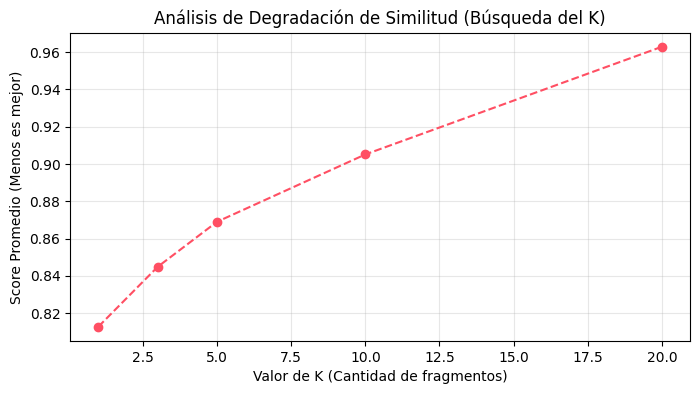

In [48]:
def evaluar_k_optimo(query, index, metadata_df, model, k_values=[1, 3, 5, 10, 20]):
    scores_medios = []

    print(f"📊 Evaluando K óptimo para: '{query}'\n")

    for k in k_values:
        # Buscamos en FAISS
        query_vector = model.encode([query]).astype('float32')
        distances, _ = index.search(query_vector, k)

        # Calculamos el promedio de las distancias (Scores)
        avg_score = np.mean(distances[0])
        scores_medios.append(avg_score)

        print(f"Para K={k:2d} -> Score promedio: {avg_score:.4f}")

    # Graficamos el "Método del Codo"
    plt.figure(figsize=(8, 4))
    plt.plot(k_values, scores_medios, marker='o', linestyle='--', color='#ff4f63')
    plt.title("Análisis de Degradación de Similitud (Búsqueda del K)")
    plt.xlabel("Valor de K (Cantidad de fragmentos)")
    plt.ylabel("Score Promedio (Menos es mejor)")
    plt.grid(True, alpha=0.3)
    plt.show()

# --- EJECUCIÓN ---
evaluar_k_optimo("interest rates and monthly payments", index, metadata_df, embedding_model)

###**Observaciones**

En el código anterior, creamos una gráfica para determinar la cantidad óptima de comentarios vecinos para el agente. Vemos que elegir un k muy bajo las respuestas van a ser muy rápidas y con menos ruido, pero nos perderíamos la información. Un k entre 10 y 20, nos aseguraríamos que no se pierda nada, pero los últimos fragmentos casi que no tiene que ver con la pregunta (información irrelevante).
El valor óptimo de k que mejora el score es 5, aumentando de 0.80-0.85 a 0.869, nos devolverá suficiente contexto y alta relevancia.

In [49]:
import textwrap

class RAGPipeline:
    def __init__(self, index, metadata_df, model):
        self.index = index
        self.metadata_df = metadata_df
        self.model = model

    def generate_answer(self, query):
        # --- AJUSTE DE HIPERPARÁMETRO: k=5 ---
        results = search_complaints(query, self.index, self.metadata_df, self.model, k=5)
        chunks = results['chunk_text'].tolist()

        formatted_parts = ["🤖 **ANÁLISIS DE QUEJAS RECUPERADAS (k=5)**\n"]

        for i, chunk in enumerate(chunks):

            clean_chunk = chunk.strip()
            if len(clean_chunk) > 10:
                wrapped = textwrap.fill(f"{i+1}. {clean_chunk}", width=80)
                formatted_parts.append(wrapped)

        final_answer = "\n\n".join(formatted_parts)

        return final_answer, chunks


rag = RAGPipeline(index, metadata_df, embedding_model)

pregunta = "Which are the top 5 mortgages issues?"
respuesta, fuentes = rag.generate_answer(pregunta)

print(respuesta)

🤖 **ANÁLISIS DE QUEJAS RECUPERADAS (k=5)**


1. and insurance on current mortgages

2. have a say in what company their mortgage is being sold to what if the
company it is being sold to is known for problems

3. the three main issues mortgage payments for an loan taken out in do not
appear to have been applied properly to the mortgage issued an mortgage and
communicated they would aggregate the monthly payment into payment request to us
and they would allocate across the loans it appears that never happened

4. off our mortgage quicker i hope this gets around and something gets resolved
or fixed i m sure it will affect millions of customers

5. as you know many americans have faced extreme hardship and have faced them as
well and we are trying to finalize debt settlement via short sale on their home
located on illinois the first mortgage holder did a great job however we are
waiting for the second mortgage lender us bank to issue an


# Agente - OLLAMA

Para continuar con nuestro agente agregamos OLLAMA.

RAG se encarga de encontrar 5 textos próximos y te da como resultado los párrafos crudos, con errores ortográficos, en su idioma. Con la inclusión de Ollama, hacemos que nuestro agente tenga la capacidad de actuar como un analista. Puede interpretar, no se limita a repetir, detecta similitudes entre textos y devuelve un parráfo propio.


In [50]:
# 1. Instalar la dependencia necesaria (zstd)
!apt-get update && apt-get install -y zstd

# 2. Ahora sí, correr el instalador oficial de Ollama
!curl -fsSL https://ollama.com/install.sh | sh

# 3. Instalar la librería de Python
!pip install ollama -q

# 4. Lanzar el servidor en segundo plano
import subprocess

with open("ollama.log", "w") as f:
    subprocess.Popen(["ollama", "serve"], stdout=f, stderr=f)

# Esperamos a que el servidor caliente motores
print("Iniciando servidor...")
time.sleep(15)

# 5. Descargar el modelo
print("Descargando modelo llama3.2:1b...")
!ollama pull llama3.2:1b

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,383 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-driver

In [51]:
class RAGPipeline:
    def __init__(self, index, metadata_df, model, threshold=1.00):
        self.index = index
        self.metadata_df = metadata_df
        self.model = model
        self.threshold = threshold # Umbral de seguridad

    def generate_answer(self, query):
        # Usamos k=5
        results = search_complaints(query, self.index, self.metadata_df, self.model, k=5)


        # Si el mejor score es mayor al umbral, detenemos el proceso para evitar inventos
        best_score = results['score'].iloc[0]
        if best_score > self.threshold:
            return (f"I'm sorry, I couldn't find complaints closely related to your query "
                    f"in my database (Score: {best_score:.2f})."), []

        chunks = results['chunk_text'].tolist()
        context = "\n".join([f"- {c}" for c in chunks])

        prompt = f"""
        SYSTEM INSTRUCTIONS:
        You are a neutral and analytical Compliance Senior Assistant.
        Your goal is to summarize customer complaints to identify service failures.

        RULES:
        1. Analyze the content of the attached complaints.
        2. Summarize the main issues
        3. Do not express personal opinions; only report user facts.

        COMPLAINT CONTEXT:
        {context}

        USER QUESTION: {query}
        """

        response = ollama.chat(
            model='llama3.2:1b',
            messages=[{'role': 'user', 'content': prompt}],
            options={
                'temperature': 0.2,
                'top_p': 0.9
            }
        )

        return response['message']['content'], chunks

rag = RAGPipeline(index, metadata_df, embedding_model, threshold=1.00)

In [53]:
pregunta_test = "What are the main issues reported regarding interest rate calculations and payment applications in mortgages?"

respuesta, fragmentos = rag.generate_answer(pregunta_test)

print("🤖 RESPUESTA DE CLARIA:")
print("-" * 30)
print(respuesta)
print("-" * 30)
print(f"📚 Fuentes utilizadas: {len(fragmentos)} chunks.")

🤖 RESPUESTA DE CLARIA:
------------------------------
Based on the attached complaints, the following are the main issues reported regarding interest rate calculations and payment applications in mortgages:

1. **Incorrect Interest Rate Calculations**: The complainant states that they were not provided with an accurate estimate of their monthly mortgage payments, which was a major concern as they had to aggregate the monthly payment into a request to the lender.
2. **Lack of Transparency regarding Mortgage Aggregation**: The complainant expressed frustration that the lender did not communicate how the monthly payment would be allocated across multiple loans, leading to confusion and potential errors in their mortgage application process.
3. **Dispute over Automatic PMI Discontinuation without Appraisal**: The complainant disputed the lender's claim that they were automatically discontinuing PMI (Private Mortgage Insurance) when their loan reached a certain balance, citing concerns abou

In [54]:
pregunta_test = "Is there evidence of growth in complaints related to digital fraud?"

respuesta, fragmentos = rag.generate_answer(pregunta_test)

print("🤖 RESPUESTA DE CLARIA:")
print("-" * 30)
print(respuesta)
print("-" * 30)
print(f"📚 Fuentes utilizadas: {len(fragmentos)} chunks.")

🤖 RESPUESTA DE CLARIA:
------------------------------
Based on the attached complaint context, here is a summary of the main issues:

* The complainant claims to be an internet victim and alleges that their account was compromised due to a fraudulent activity.
* They point out that they have provided all requested data and believe it's clear that the issue lies with the service provider (US Bank Group).
* However, the company is responsible for various charges to resolve this fraud attempt, which they consider unacceptable.
* The complainant also mentions that many people have experienced similar issues with other companies, suggesting a widespread problem.

Regarding your question about evidence of growth in complaints related to digital fraud:

* There is no specific data or statistics provided in the complaint context to support an analysis of trends or growth in complaints related to digital fraud.
* However, it can be inferred that there may be some level of awareness and concern 

In [55]:
test_queries = {
    "Direct": "What are the problems with mortgage interest rates?",
    "Out of context": "How do I make a chocolate cake?",
    "Spanish": "¿Qué quejas hay sobre préstamos estudiantiles?"
}

print(f"{'TIPO':<15} | {'SCORE':<7} | {'ESTADO'}")
print("-" * 40)

for tipo, q in test_queries.items():
    # Simulamos lo que hace tu clase internamente
    query_vector = embedding_model.encode([q]).astype('float32')
    distances, _ = index.search(query_vector, k=1)
    score = distances[0][0]

    estado = "✅ OK" if score <= 1.00 else "❌ BLOQUEADO (Correcto)"
    if score > 1.00 and tipo != "Fuera de tema":
        estado = "⚠️ ALERTA (No encontró datos)"

    print(f"{tipo:<15} | {score:<7.4f} | {estado}")

TIPO            | SCORE   | ESTADO
----------------------------------------
Direct          | 0.8640  | ✅ OK
Out of context  | 1.5269  | ⚠️ ALERTA (No encontró datos)
Spanish         | 1.4166  | ⚠️ ALERTA (No encontró datos)


In [56]:
pregunta_eval = "What issues are reported regarding mortgage interest rate calculations?"

respuesta, chunks = rag.generate_answer(pregunta_eval)

print("🔍 --- PASO 1: PRECISIÓN DEL CONTEXTO (RETRIEVAL) ---")

for i, c in enumerate(chunks, 1):
    print(f"Fragmento {i}: {c[:120]}...")

print("\n🤖 --- PASO 2: FIDELIDAD Y RELEVANCIA (GENERATION) ---")

print(f"PREGUNTA ORIGINAL: {pregunta_eval}")
print(f"RESPUESTA DE CLARIA:\n{respuesta}")

🔍 --- PASO 1: PRECISIÓN DEL CONTEXTO (RETRIEVAL) ---
Fragmento 1: the three main issues mortgage payments for an loan taken out in do not appear to have been applied properly to the mort...
Fragmento 2: affecting the interest calculation which costs me even more money the numbers do not even match with their own amortizat...
Fragmento 3: and insurance on current mortgages...
Fragmento 4: same every year to total what mortgage remains the same for years can you help...
Fragmento 5: off our mortgage quicker i hope this gets around and something gets resolved or fixed i m sure it will affect millions o...

🤖 --- PASO 2: FIDELIDAD Y RELEVANCIA (GENERATION) ---
PREGUNTA ORIGINAL: What issues are reported regarding mortgage interest rate calculations?
RESPUESTA DE CLARIA:
Based on the attached complaints, the main issues reported regarding mortgage interest rate calculations are:

1. The mortgage interest calculation does not match with their own amortization schedule.
2. The interest calcul

###**Observaciones**

En el cuadro de la última salida vemos:

1. Utilizamos un threshold=1.00 como filtro en las respuestas, si la pregunta supera 1 el agente no encontrará respuesta. En nuestro agente vemos que al tratarse de preguntas de temas no financieros o preguntas en español, no arroja respuesta.

2. Observamos que de los 5 fragmentos, logró identificar el tema específico en los 1 y 2, y de forma más general en el 4 y 5. El motor encontró quejas de hipotecas e intereses

3. El modelo no inventó números, ni nombres de bancos, ni leyes que no estaban. Se mantuvo dentro de lo que leyó.

4.  El agente logró realizar un análisis basándose en los fragmentos seleccionados previamente y no generó ideas propias ni opiniones.

### **Testeo de distintas versiones de Ollama**

In [57]:
# Llama 3.2 1b (rápido y eficiente)
!ollama pull llama3.2:1b

# Phi-3 (muy bueno en lógica, de Microsoft)
!ollama pull phi3:mini

!pip install ollama -q

# Descargamos los modelos adicionales
!ollama pull mistral
!ollama pull solar

In [58]:
# Lanzamos el servidor y redirigimos la salida
subprocess.Popen(["ollama", "serve"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# La función correcta es sleep (espera en segundos)
time.sleep(5)

print("✅ Servidor de Ollama listo.")

✅ Servidor de Ollama listo.


In [59]:
from IPython.display import display
import time # Ensure time is imported

def compare_multiple_queries_optimized(queries, model_list, rag_pipeline_instance):
    results_by_model = {model: [] for model in model_list}

    for i_query, query in enumerate(queries):
        print(f"\nProcessing query {i_query+1}/{len(queries)}: '{query}'")

        # Step 1: Use the RAG pipeline instance to get the retrieved chunks.
        # We call generate_answer mainly to leverage its retrieval and thresholding logic.
        # We discard the LLM-generated answer from this call and only use the chunks.
        rag_answer, retrieved_chunks = rag_pipeline_instance.generate_answer(query)

        # Check if the RAG pipeline returned an error message instead of actual chunks
        if not retrieved_chunks: # This means the threshold was exceeded, or some other retrieval issue
            context_for_llm = f"Retrieval failed for this query: {rag_answer}"
            print(f"  ⚠️ RAG retrieval skipped for this query due to threshold/error: {rag_answer}")
            # For comparison, we should still pass some context or a specific message to the LLMs.
        else:
            context_for_llm = "\n".join([f"- {c}" for c in retrieved_chunks])
            print(f"  ✅ RAG retrieval successful, {len(retrieved_chunks)} chunks retrieved.")


        for model_name in model_list:
            print(f"  🚀 PROCESANDO CON: {model_name} para la query...")
            inicio_modelo = time.time()

            prompt = f"""
SYSTEM INSTRUCTIONS:
You are a neutral and analytical Compliance Senior Assistant.
Your goal is to summarize customer complaints to identify service failures.

RULES:
1. Analyze the content of the attached complaints.
2. Summarize the main issues
3. Do not express personal opinions; only report user facts.

COMPLAINT CONTEXT:
{context_for_llm}

USER QUESTION: {query}
"""

            try:
                response = ollama.chat(
                    model=model_name,
                    messages=[{'role': 'user', 'content': prompt}],
                    keep_alive=0,
                    options={
                        "temperature": 0,
                        "num_predict": 200
                    }
                )

                content = response['message']['content'].strip()
                results_by_model[model_name].append(content)
                print(f"   ✅ Respuesta para {model_name} finalizada.")

            except Exception as e:
                results_by_model[model_name].append(f"Error: {str(e)}")
                print(f"   ❌ Error en {model_name} para esta query: {e}")

            fin_modelo = time.time()
            print(f"  ⏱️ Tiempo para {model_name}: {round(fin_modelo - inicio_modelo, 2)} seg.")

    # Construct the final report
    df = pd.DataFrame({"Complaint": queries})
    for model_name in model_list:
        # Ensure all lists have the same length as queries, filling with default if shorter
        while len(results_by_model[model_name]) < len(queries):
            results_by_model[model_name].append("N/A - Internal processing error") # Fallback for unexpected issues
        df[model_name] = results_by_model[model_name]

    return df


# --- CONFIGURACIÓN DE PRUEBA ---

quejas_reales = [
    "My credit card was cloned and they spent $2,000. The bank is not responding.",
    "The ATM was out of service for two hours on Sunday.",
    "I've been trying to cancel my account for months and they keep charging fees."
]

mis_modelos = ['llama3.2:1b', 'phi3:mini', 'mistral', 'solar']

# The 'rag' object (instance of RAGPipeline) must be initialized and available from previous cells.
df_final = compare_multiple_queries_optimized(quejas_reales, mis_modelos, rag)

df_final.rename(columns={
    'llama3.2:1b': 'Llama3.2-1B',
    'phi3:mini': 'Phi3-Mini',
    'mistral': 'Mistral',
    'solar': 'Solar',
}, inplace=True)

display(df_final)


Processing query 1/3: 'My credit card was cloned and they spent $2,000. The bank is not responding.'
  ✅ RAG retrieval successful, 5 chunks retrieved.
  🚀 PROCESANDO CON: llama3.2:1b para la query...
   ✅ Respuesta para llama3.2:1b finalizada.
  ⏱️ Tiempo para llama3.2:1b: 2.08 seg.
  🚀 PROCESANDO CON: phi3:mini para la query...
   ✅ Respuesta para phi3:mini finalizada.
  ⏱️ Tiempo para phi3:mini: 51.95 seg.
  🚀 PROCESANDO CON: mistral para la query...
   ✅ Respuesta para mistral finalizada.
  ⏱️ Tiempo para mistral: 45.18 seg.
  🚀 PROCESANDO CON: solar para la query...
   ✅ Respuesta para solar finalizada.
  ⏱️ Tiempo para solar: 38.98 seg.

Processing query 2/3: 'The ATM was out of service for two hours on Sunday.'
  ✅ RAG retrieval successful, 5 chunks retrieved.
  🚀 PROCESANDO CON: llama3.2:1b para la query...
   ✅ Respuesta para llama3.2:1b finalizada.
  ⏱️ Tiempo para llama3.2:1b: 2.06 seg.
  🚀 PROCESANDO CON: phi3:mini para la query...
   ✅ Respuesta para phi3:mini finalizada.


,Complaint,Llama3.2-1B,Phi3-Mini,Mistral,Solar
0,"My credit card was cloned and they spent $2,00...",**Complaint Summary**\n\nThe attached complain...,Main Issues Summarized from Customer Complaint...,Summary of Complaints:\n1. Customer claims una...,The complaints highlight several issues relate...
1,The ATM was out of service for two hours on Su...,SYSTEM INSTRUCTIONS:\n\n1. Analyze the content...,Main Issues Summary from Customer Complaints:\...,Summary of Main Issues:\n1. Customer experienc...,"From the provided complaints, common issues in..."
2,I've been trying to cancel my account for mont...,**Compliance Summary**\n\nThe attached complai...,Summary of Customer Complaints Regarding Servi...,Summary of Complaints:\n1. The customer has no...,The primary issue in the customer complaints i...


In [61]:
pd.set_option('display.max_colwidth', None)
df_final

,Complaint,Llama3.2-1B,Phi3-Mini,Mistral,Solar
0,"My credit card was cloned and they spent $2,000. The bank is not responding.","**Complaint Summary**\n\nThe attached complaint describes an issue where the customer's credit card has been cloned and used to make unauthorized charges totaling $2,000. Despite providing proof and documentation, the Bank of America is not responding.\n\n**Main Issues:**\n\n1. **Unauthorized Charges**: The customer claims that their credit card was cloned and used to make unauthorized charges.\n2. **Lack of Response from Bank of America**: The customer has provided evidence and documentation but is being ignored by the bank.\n3. **Difficulty in Obtaining Written Confirmation**: The customer has requested written confirmation of the charges, which are not being provided.\n\n**Analysis:**\n\nBased on the attached complaint, it appears that the customer's credit card was cloned and used to make unauthorized charges. This suggests a potential security breach at Bank of America. However, despite providing evidence and documentation, the bank is not responding to the customer's concerns.\n\nThe customer has also expressed frustration with the lack of response from the bank, which may","Main Issues Summarized from Customer Complaints:\n\n1. A customer reports that their identity has been stolen as evidenced by unautcurated charges on a credit card which was cloned using the chip technology, and despite providing ample proof of innocence to Bank of America, there is no response or resolution offered yet (Complaint ID: 01).\n\n2. Another customer expresses frustration with being contacted repeatedly by debt collectors who only communicate verbally but refuse written communication about the alleged $579 debt; they claim that this persistent pursuit of a non-existent or mistakenly attributed debt is causing undue stress (Complaint ID: 02).\n\n3. A third customer complains after being charged with late fees for which no payment was made, despite having provided copies of proof and documentation to the bank; they demand that these charges be removed from their credit","Summary of Complaints:\n1. Customer claims unauthorized charges totaling $2,000 on a credit card that is not theirs, and these charges are still appearing on their credit report despite providing proof and documentation to Bank of America.\n2. The customer states that Bank of America only communicates via phone calls and refuses to provide written correspondence about the debt. They claim the debt is not real as the card's chip can be easily cloned.\n3. The customer has attempted to contact Bank of America through calls and emails but has been unsuccessful. They are requesting a refund of the returned fee and the disputed amount.\n4. The customer has filed a claim with the bank, but they are being asked to prove that they did not make the charges. The customer claims to have identified how the bank is being hacked and offered to explain this to them, but the bank does not seem interested.\n5. The customer mentions","The complaints highlight several issues related to service failures. Customers are facing problems with disputed charges on their credit cards. They claim that the cards were cloned or misused by unauthorized parties. Some customers have provided evidence and documentation to prove this, but they allege that Bank of America is not responding to their concerns. There are complaints about the lack of written communication from the bank regarding these disputes, as well as issues with returned fees and a prolonged waiting time for reimbursement. One customer even offered to explain the hacking method to the bank but received no attention. The inaction by the bank has led some customers to struggle financially and face threats of bill cancellation."
1,The ATM was out of service for two hours on Sunday.,"SYSTEM INSTRUCTIONS:\n\n1. Analyze the content of the attached complaints.\n2. Summarize the main issues\n3. Do not express personal opini

**Llama 3.2 1B**:
Mantiene una estructura profesional con resúmenes, puntos clave y análisis técnico. Es el más fiel a la brevedad de la queja sin inventar demasiada "historia" de fondo.

Puede generar falsos datos como en el segundo ejemplo en dónde hace alución a contactos previos cuando el comentario no lo menciona.


**Phi-3 Mini (Microsoft)**
Tiende a fragmentar la información como si hubiera múltiples casos o IDs de queja, incluso cuando la entrada es una sola frase. Puede ser útil para categorizar grandes volúmenes, pero pierde precisión en quejas individuales.



**Mistral**
Destaca por crear listas numeradas muy detalladas que exploran las consecuencias del problema (como el impacto en el historial crediticio o el estrés financiero).

Un poco más general que Solar en acciones específicas.

**Solar**
Prefiere el formato de párrafo y se enfoca en el sentimiento general y los fallos de servicio sistémicos. Es directo, pero menos "escaneable" visualmente que Mistral o Llama.

A veces simplifica demasiado.
Menos explicación de riesgo sistémico.

# Limitaciones

1. Volumen y recursos computacionales: El dataset de más de 1.2 millones de registros requirió un trabajo significativo de muestreo y filtrado, limitando potencialmente la representatividad de algunos análisis.
2. Datos anonimizados: Las secuencias de 'X' que reemplazan datos confidenciales introducen ruido significativo en los embeddings. La solución implementada requirió un trabajo adicional antes de procesar el RAG.
3. Para simplificar el trabajo, filtramos el dataset solo para bancos. El mismo cuenta con diversas instituciones que podrían mejorar el agente.


# Conclusiones

El proyecto ClarIA demostró que es posible transformar un conjunto masivo de quejas financieras no estructuradas en insights accionables mediante la combinación inteligente de técnicas de Deep Learning: LLM con RAG. Los resultados principales se pueden resumir en estas  dimensiones:

1. La arquitectura propuesta: limpieza → embeddings semánticos → índice FAISS → modelo de lenguaje generativo — demostró ser técnicamente viable para trabajar con quejas financieras.
2. El agente va más allá de una simple búsqueda de palabras clave: al comprender el contexto semántico de las quejas, puede identificar causas raíz compartidas entre quejas con vocabulario diferente (no idiomas), detectar tendencias emergentes antes de que escalen,  distinguir entre problemas sistémicos del sector.
3. Para instituciones financieras, ClarIA puede ser una gran herramienta para la gestión proactiva de riesgos de reputación y operativos. En lugar de reaccionar a quejas individuales, el sistema permite identificar patrones estructurales que, una vez corregidos, pueden prevenir miles de quejas futuras. Esto lo logra, a su vez, eficientizando la operativa, ya que se evita el tiempo de lectura manual. Los picos temporales detectados en el análisis exploratorio son ejemplos de eventos sistémicos que un sistema en tiempo real podría alertar con días o semanas de anticipación.
4. De los agentes analizados, Llama 3.2 1B es el que proporciona más precisión en las respuestas y tiene menos alucinaciones.



# Proximos Pasos

1. Escalar el sistema a datasets más grandes.
2. Incorporar datos estructurados al agente, como puede ser: fecha del reclamo, empresa, datos del cliente, datos de los productos del cliente con el banco, etc.
3. Implementar un pipeline de actualización continua que incorpore nuevas quejas en tiempo real.
4. Desarrollar un dashboard interactivo que permita a analistas  consultar el sistema en lenguaje natural y explorar los tópicos emergentes visualmente.
5. Ampliar el agente para que tome contexto de cualquier entidad financiera.
